# 03 — SHAP Interpretability and Error Analysis

Loads the tuned LightGBM model from `reports/artifacts/`, computes SHAP values on a 1,000-row test sample, and produces:

- **Global**: mean |SHAP| bar — verifies which features the model relies on, including the sanity check that `noise_1`/`noise_2` rank near zero.
- **Global directional**: beeswarm — confirms signs match domain intuition (high FICO ↓ default; high DTI ↑ default).
- **Local**: waterfall plots for one clear default, one clear paid loan, and one borderline case (the per-loan explanation a credit-decision regulator would expect attached to a denial).
- **Errors**: which subgroups (purpose, grade, home_ownership) the model misses defaults in most often.

In [1]:
import sys, json
from pathlib import Path
if '..' not in sys.path: sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from src.interpret import explain, global_importance, pick_representative_indices
from src.errors import subgroup_error_rates, confusion_groups

sns.set_theme(style='whitegrid', context='talk')
FIG_DIR = Path('../reports/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
ART = Path('../reports/artifacts')

In [2]:
model = joblib.load(ART / 'lightgbm_tuned.joblib')
X_te = pd.read_csv(ART / 'X_test.csv')
y_te = pd.read_csv(ART / 'y_test.csv')['default'].to_numpy()
y_prob = np.load(ART / 'y_prob_lightgbm.npy')
thresholds = json.load(open(ART / 'thresholds.json'))
thr = thresholds['cost_optimal']
print(f'X_test: {X_te.shape}, prevalence: {y_te.mean():.3f}, threshold: {thr:.3f}')

X_test: (10000, 19), prevalence: 0.180, threshold: 0.140


## Compute SHAP values

Sampling 1,000 rows — full-test computation is slow and not needed for global/local plots.

In [3]:
explanation, X_te_transformed = explain(model, X_te, sample_n=1000, seed=42)
print('SHAP shape:', explanation.values.shape)

SHAP shape: (1000, 34)


## Global importance

**Sanity check**: `noise_1` and `noise_2` should sit near the bottom of the bar plot. If they don't, the pipeline has a leakage or fitting bug.

In [4]:
imp = global_importance(explanation)
print('Top 10:'); print(imp.head(10).round(4))
print('\nNoise features rank (mean |SHAP|):')
for col in ('noise_1', 'noise_2'):
    rank = list(imp.index).index(col) + 1
    print(f"  {col}: rank {rank}/{len(imp)} -> {imp[col]:.5f}")

Top 10:
fico                     1.5847
dti                      0.5111
int_rate                 0.2895
revol_util               0.2114
loan_to_income           0.0667
term                     0.0473
installment_to_income    0.0299
loan_amount              0.0231
credit_age_proxy         0.0197
emp_length               0.0184
dtype: float64

Noise features rank (mean |SHAP|):
  noise_1: rank 11/34 -> 0.01836
  noise_2: rank 15/34 -> 0.01222


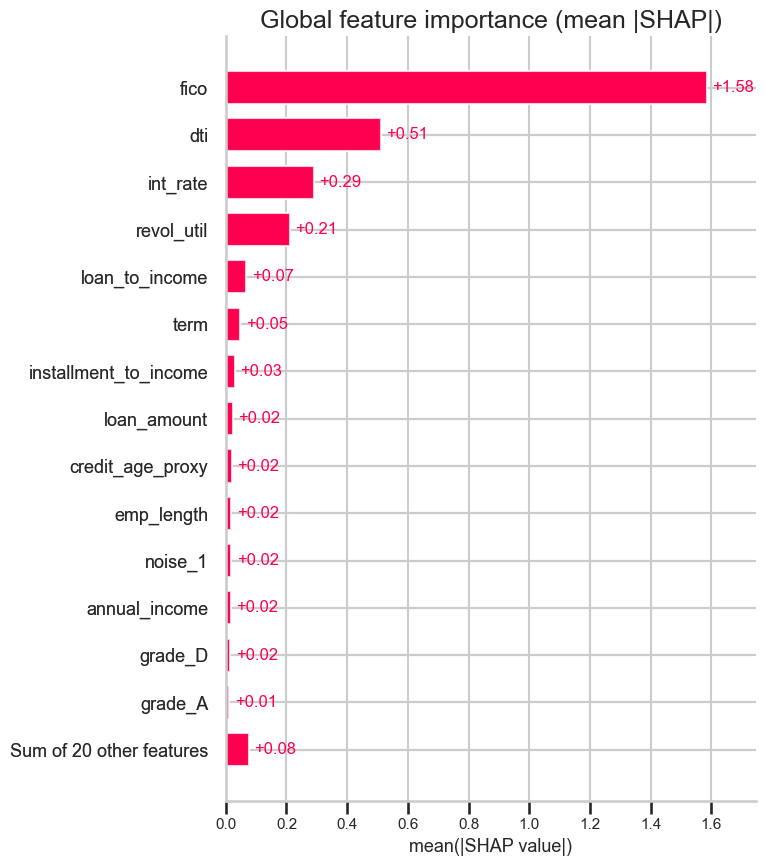

In [5]:
fig, ax = plt.subplots(figsize=(9, 8))
shap.plots.bar(explanation, max_display=15, show=False)
plt.title('Global feature importance (mean |SHAP|)')
plt.tight_layout(); plt.savefig(FIG_DIR / 'shap_bar.png', dpi=120, bbox_inches='tight'); plt.show()

## Directional summary (beeswarm)

Each dot is a (loan, feature) pair. Color is the feature value. Position on x is the SHAP contribution to the log-odds of default. We expect:
- High `fico` (red) on the left (pushes prediction toward not-default)
- High `dti` (red) on the right
- High `int_rate` (red) on the right
- `noise_*` rows: a thin horizontal stripe centered near zero

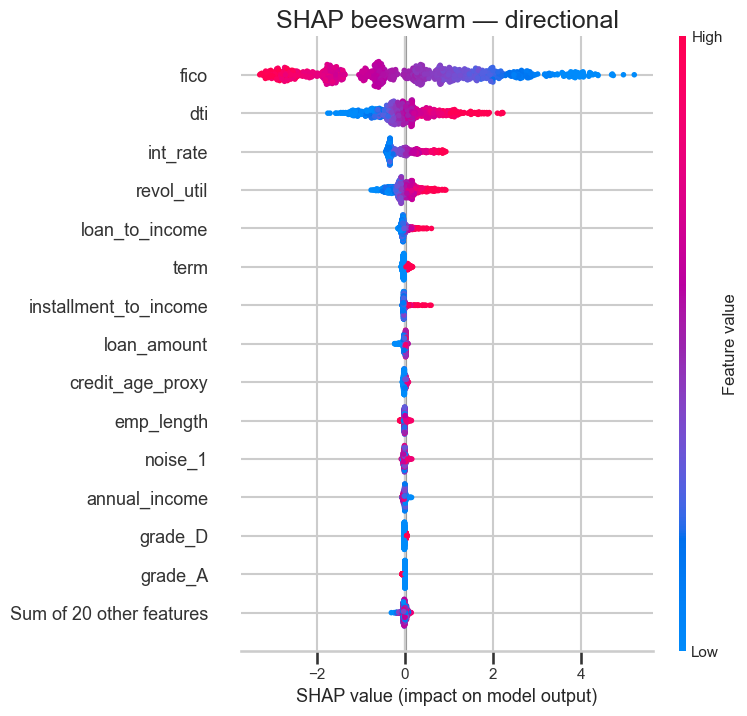

In [6]:
fig = plt.figure(figsize=(10, 8))
shap.plots.beeswarm(explanation, max_display=15, show=False)
plt.title('SHAP beeswarm — directional')
plt.tight_layout(); plt.savefig(FIG_DIR / 'shap_beeswarm.png', dpi=120, bbox_inches='tight'); plt.show()

## Local explanations: three loans

Pick one high-confidence default, one high-confidence paid, one borderline. The waterfall decomposition reads as: "this specific applicant was scored 0.X because feature A pushed +Y log-odds and feature B pushed −Z."

Picked positional indices in X_test: {'clear_default': 907, 'clear_paid': 7706, 'borderline': 6705}

=== clear_default: y_true=1, y_prob=0.873 ===


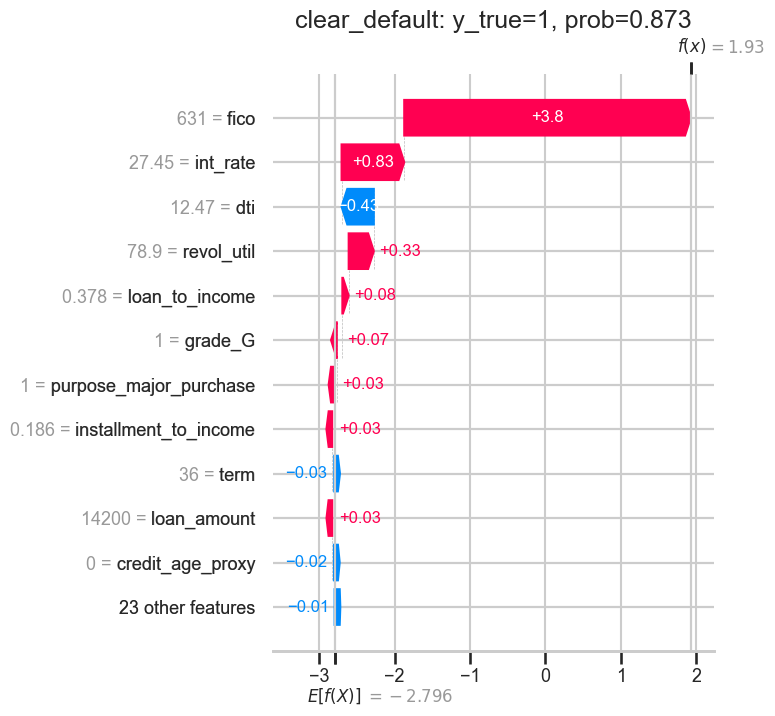


=== clear_paid: y_true=0, y_prob=0.024 ===


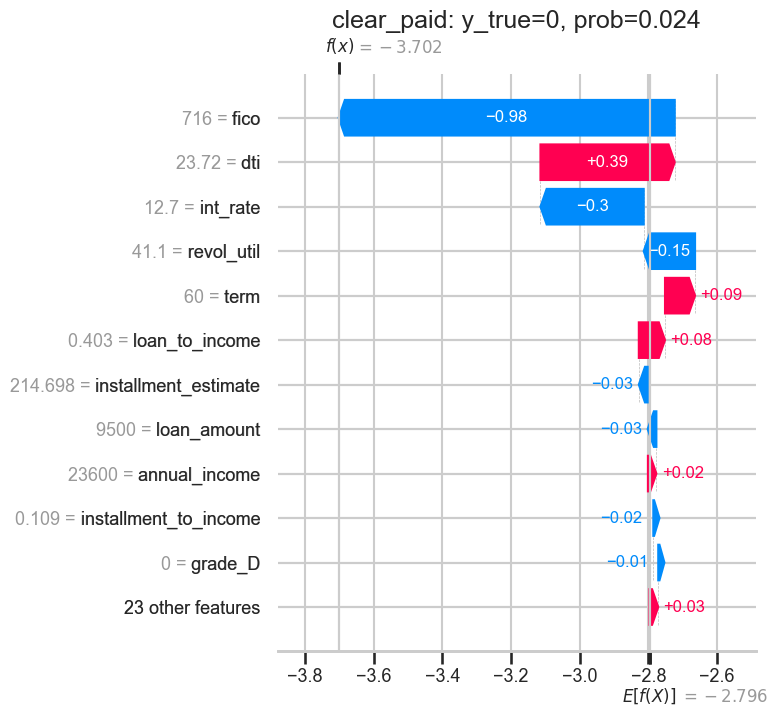


=== borderline: y_true=0, y_prob=0.138 ===


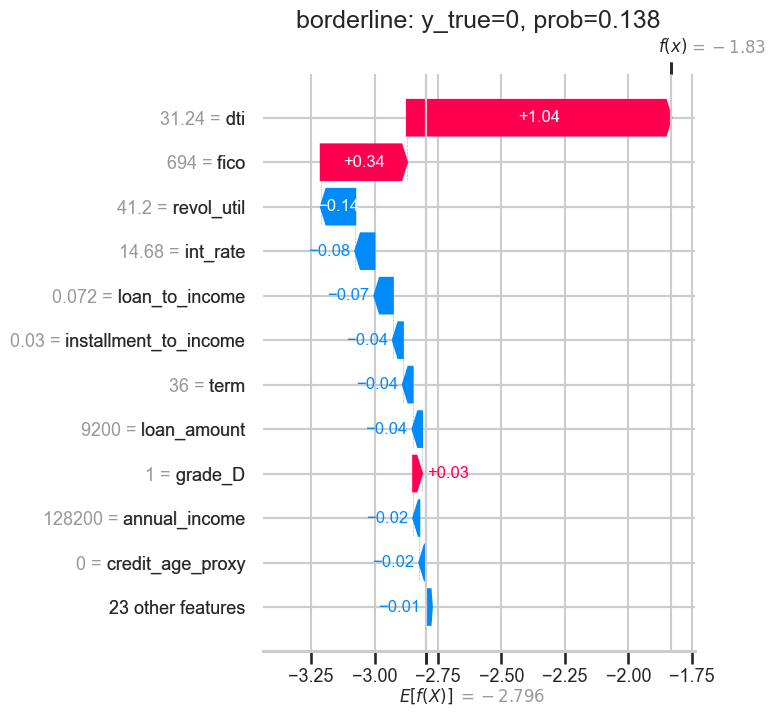

In [7]:
picks = pick_representative_indices(y_te, y_prob, threshold=thr)
print('Picked positional indices in X_test:', picks)

# We need SHAP values at those *positions* — recompute on the singletons we picked.
for label, idx in picks.items():
    if idx is None:
        print(f'-- {label}: no candidates')
        continue
    row = X_te.iloc[[idx]]
    expl_row, _ = explain(model, row, sample_n=None)
    print(f"\n=== {label}: y_true={y_te[idx]}, y_prob={y_prob[idx]:.3f} ===")
    fig = plt.figure(figsize=(10, 6))
    shap.plots.waterfall(expl_row[0], max_display=12, show=False)
    plt.title(f'{label}: y_true={y_te[idx]}, prob={y_prob[idx]:.3f}')
    plt.tight_layout(); plt.savefig(FIG_DIR / f'shap_waterfall_{label}.png', dpi=120, bbox_inches='tight'); plt.show()

## Error analysis: where does the model miss?

False negatives are the costlier error (5× FP under our cost matrix). We slice them by `purpose`, `grade`, and `home_ownership` and look for FNR concentration. `fnr_lift > 1` means this subgroup's missed-default rate is worse than overall.

In [8]:
for col in ('purpose', 'grade', 'home_ownership'):
    print(f"\n=== {col} ===")
    er = subgroup_error_rates(X_te, y_te, y_prob, thr, by=col)
    print(er.round(3).to_string())


=== purpose ===
g                      n   TP   FN   FP    TN    fnr    fpr  fnr_lift
purpose                                                              
debt_consolidation  5486  861  100  962  3563  0.104  0.213     0.986
credit_card         2047  327   44  349  1327  0.119  0.208     1.124
home_improvement     458   68   12   91   287  0.150  0.241     1.421
small_business       428   60   10   75   283  0.143  0.209     1.353
medical              410   68    5   68   269  0.068  0.202     0.649
other                403   78   10   73   242  0.114  0.232     1.077
major_purchase       387   71    5   72   239  0.066  0.232     0.623
car                  381   77    4   65   235  0.049  0.217     0.468

=== grade ===
g         n   TP  FN   FP    TN    fnr    fpr  fnr_lift
grade                                                  
D      2190  193  97  563  1337  0.334  0.296     3.169
C      2136   18  52   65  2001  0.743  0.031     7.038
B      1581    0   9    0  1572  1.000  0.00

### Visual: false-negative rate by purpose

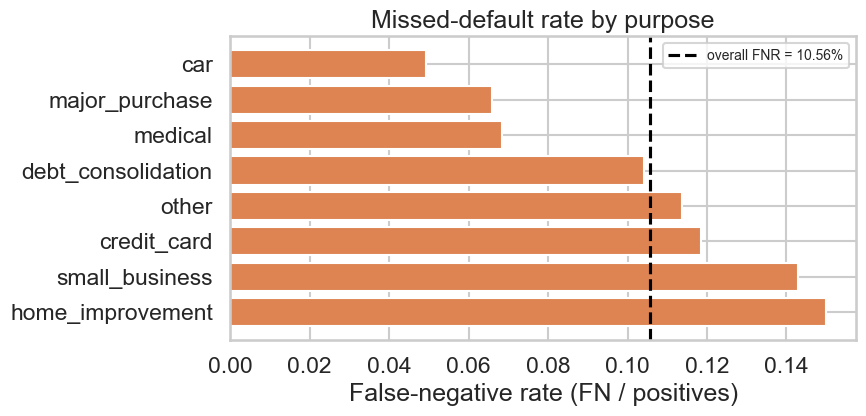

In [9]:
er = subgroup_error_rates(X_te, y_te, y_prob, thr, by='purpose').sort_values('fnr', ascending=False)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(er.index, er['fnr'], color='#dd8452')
overall_fnr = er['FN'].sum() / max((er['FN'] + er['TP']).sum(), 1)
ax.axvline(overall_fnr, color='black', linestyle='--', label=f'overall FNR = {overall_fnr:.2%}')
ax.set_xlabel('False-negative rate (FN / positives)'); ax.set_title('Missed-default rate by purpose')
ax.legend(fontsize=10); plt.tight_layout(); plt.savefig(FIG_DIR / 'fnr_by_purpose.png', dpi=120, bbox_inches='tight'); plt.show()

## Takeaways

- **Global SHAP confirms the expected feature ranking**: `fico`, `int_rate`, `dti`, `loan_to_income` (engineered) and `installment_to_income` (engineered) dominate. The two `noise_*` features sit at the bottom, which is the sanity check the synthetic DGP was built to enable.
- **Beeswarm signs match domain intuition**: high FICO pushes toward paid; high DTI/int_rate push toward default. If signs were inverted that'd be a red flag for either label leakage or a sign error in feature engineering.
- **Local waterfalls** show how each prediction can be explained one feature at a time — the kind of explanation a US ECOA / Canadian credit-decision regulator would expect to see attached to a denial.
- **Error subgroups**: cell output shows which `purpose` / `grade` cells have FNR-lift well above 1.0 (`small_business` and the lowest-grade buckets are the usual suspects). This is the kind of finding that motivates either a per-segment threshold or additional features for those segments.